In [2]:
# ==========================================
import gc
import os
import warnings
from functools import reduce
from itertools import combinations
from typing import Any, Dict, List, Optional, Tuple, Union
# ==========================================
import dask
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import kurtosis, skew
# ==========================================
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
# ==========================================
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter # For coordinate tick labels
from shapely.ops import unary_union
# ==========================================

In [3]:
raw_data_folder = "./data/raw/"
kumasi_lat = 6.68848
kumasi_lon = -1.62443

In [4]:
def standardize_SEAS5(ds: xr.Dataset, variable_name: Optional[str] = None) -> xr.Dataset:
    """
    Standardize coordinate names for SEAS5 NetCDF files and compute validity times.
    Optionally, it can standardize units for a specific variable, managing both
    monthly rates and daily accumulated variables.

    This function renames standard coordinates (latitude, longitude, ensemble member, initialization time)
    to a common convention. It automatically detects whether the dataset is daily or monthly based on
    available coordinates.

    For **both monthly and daily datasets**, it additionally calculates/assigns:
    - `valid_time`: A 2D coordinate (init_time, lead_time) representing the actual validity date.
    - `target_month`: The specific month (1-12) derived from the validity time.
    
    Variable unit standardization:
    - If `variable_name` is "tprate" (monthly), it converts the values from m/s to mm/day.
    - If `variable_name` is "tp" (daily), it de-accumulates the precipitation (tp_t2 - tp_t1) 
      and converts the values from meters (m) to millimeters (mm).

    Parameters
    ----------
    ds : xr.Dataset
        Input xarray Dataset containing SEAS5 NetCDF data (from Copernicus CDS).
        Expected to contain coordinates like 'forecast_reference_time' and either
        'forecastMonth' (monthly) or 'forecast_period' (daily).
    variable_name : str, optional
        The name of the variable to standardize units for ("tprate" or "tp").

    Returns
    -------
    xr.Dataset
        Dataset with standardized coordinate names (lat, lon, init_time, lead_time, ensemble_member).
        It will also include `valid_time` and `target_month` coordinates, and potentially 
        converted variable units.
    """
    # Rename common coords
    ds = ds.rename({
        "latitude": "lat",
        "longitude": "lon",
        "number": "ensemble_member",
        "forecast_reference_time": "init_time",
    })

    # Flag to track dataset temporal resolution
    is_daily = False

    if "forecast_period" in ds.coords:
        is_daily = True
        # It's a daily dataset
        ds = ds.rename({
            "forecast_period": "lead_time",
        })
        
        # cfgrib sometimes loads valid_time as a data variable instead of a coordinate.
        if "valid_time" in ds.data_vars:
            ds = ds.set_coords("valid_time")
        # Compute vectorially (datetime64 + timedelta64) if missing
        elif "valid_time" not in ds.coords:
            ds.coords['valid_time'] = ds.init_time + ds.lead_time

        # 'target_month' created from 'valid_time'
        ds.coords['target_month'] = ds.valid_time.dt.month

    else:
        # It's a monthly dataset
        ds = ds.rename({
            "forecastMonth": "lead_time",
        })
        
        # New coordinate system for monthly data
        # valid_time = init_time + lead_time (in months)
        inits = pd.to_datetime(ds.init_time.values)
        leads = ds.lead_time.values
        valid_times = []
        for init in inits:
            row = [(init + pd.DateOffset(months=int(lead))) for lead in leads]
            valid_times.append(row)
            
        # Convert to numpy datetime64 for compatibility with xarray
        valid_times_np = np.array(valid_times, dtype='datetime64[ns]')
        
        # Assign new coordinate 'valid_time' to the dataset
        ds = ds.assign_coords(
            valid_time=(('init_time', 'lead_time'), valid_times_np)
        )
        # 'target_month' created from 'valid_time'
        ds.coords['target_month'] = ds.valid_time.dt.month

    # Standardization of units for specific variables
    if variable_name is not None and variable_name in ds:
        
        if not is_daily and variable_name == "tprate":
            # Monthly conversion: from m/s to mm/day
            ds[variable_name] = ds[variable_name] * 1000 * 86400
            
            if 'GRIB_units' in ds[variable_name].attrs:
                ds[variable_name].attrs['GRIB_units'] = 'mm/day'
                
        elif is_daily and variable_name == "tp":
            # Daily conversion: from accumulated meters (m) to daily millimeters (mm)
            first_day = ds[variable_name].isel(lead_time=slice(0, 1))
            following_days = ds[variable_name].diff(dim='lead_time')
            ds[variable_name] = xr.concat([first_day, following_days], dim='lead_time') * 1000
            ds[variable_name].attrs['units'] = 'mm'
            if 'GRIB_units' in ds[variable_name].attrs:
                ds[variable_name].attrs['GRIB_units'] = 'mm'

    return ds


def crop_nc_to_region(ds : xr.Dataset, lat_min: float, lat_max: float, lon_min: float, lon_max: float) -> xr.Dataset:
    """
    Crop an xarray Dataset to a specified lat/lon bounding box.
    Latitudes and longitudes are in degrees. 
    Columns 'lat' and 'lon' are assumed.

    Parameters
    ----------
    ds : xr.Dataset
        Input xarray Dataset to be cropped.
    lat_min : float
        Minimum latitude of the bounding box.
    lat_max : float
        Maximum latitude of the bounding box.
    lon_min : float
        Minimum longitude of the bounding box.
    lon_max : float
        Maximum longitude of the bounding box.

    Returns
    -------
    xr.Dataset
        Cropped Dataset.
    """
    return ds.sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))



def merge_SEAS5_datasets(datasets: List[xr.Dataset]) -> xr.Dataset:
    """
    Concatenate a list of SEAS5 datasets along the 'init_time' dimension.

    This function merges datasets downloaded in separate chunks (e.g., by 
    different initialization months) that share the same spatial domain, 
    ensemble members, and lead times. It automatically sorts the resulting 
    dataset chronologically to ensure a continuous time series.

    Parameters
    ----------
    datasets : list of xarray.Dataset
        A list of xarray Datasets to be merged. All datasets are expected 
        to have been processed by `standardize_SEAS5` and must include 
        the 'init_time' coordinate.

    Returns
    -------
    xarray.Dataset
        A single, continuous Dataset concatenated and sorted along the 
        'init_time' dimension.

    Raises
    ------
    ValueError
        If the input list `datasets` is empty.
    KeyError
        If the 'init_time' coordinate is missing from the first dataset 
        in the list.
    """
    if not datasets:
        raise ValueError("The input list of datasets is empty. Please provide at least one dataset.")

    # Check for 'init_time' to prevent errors during concatenation
    if 'init_time' not in datasets[0].coords:
        raise KeyError("'init_time' coordinate not found. Ensure `standardize_SEAS5` was run.")

    # Concatenate along 'init_time'. 
    merged_ds = xr.concat(datasets, dim='init_time')
    merged_ds = merged_ds.sortby('init_time')

    return merged_ds


def add_coords_to_daily_SEAS5(ds: xr.Dataset) -> xr.Dataset:
    """
    Transforms a SEAS5 dataset by stacking temporal dimensions and calculating monthly lead times.

    This function reshapes the dataset from a 2D time structure (`init_time`, `lead_time`)
    into a flat 1D time structure (`forecast_time`). It replaces the newly stacked dimension
    with the actual validity time (`valid_time`) and calculates the lead time in months.

    Parameters
    ----------
    ds : xarray.Dataset
        The input SEAS5 dataset. Expected to have `init_time` and `lead_time` as
        dimensions, and `valid_time` as a 2D coordinate.

    Returns
    -------
    xarray.Dataset
        The transformed dataset with a single `forecast_time` dimension (which represents
        the validity time), and a new `monthly_lead_time`.

    Notes
    -----
    The `monthly_lead_time` is calculated as the integer number of months between
    the initialization time (`init_time`) and the validity time (`forecast_time`).
    """
    ds = ds.stack(forecast_time=("init_time", "lead_time"))
    ds = ds.set_index(forecast_time="valid_time")
    ds["forecast_time"].attrs = {
        "standard_name": "valid_time",
        "long_name": "validity time of the forecast",
        "description": "Exact datetime the forecast is valid for"
    }


    if "target_month" in ds.coords:
        ds["target_month"].attrs = {
            "long_name": "month of the forecast",
            "units": "month"
        }

    init_year = ds["init_time"].dt.year
    init_month = ds["init_time"].dt.month
    valid_year = ds["forecast_time"].dt.year
    valid_month = ds["forecast_time"].dt.month
    monthly_lead_time = (valid_year - init_year) * 12 + (valid_month - init_month)
    ds = ds.assign_coords(monthly_lead_time=monthly_lead_time)
    ds["monthly_lead_time"].attrs = {
        "standard_name": "forecast_period",
        "long_name": "lead time in months",
        "units": "months",
        "description": "Integer number of months between initialization and validity time"
    }
    
    return ds



In [5]:
# variable_name = "msl"
# mslp_list = []

# suffixes = np.arange(1992,2022+1,1).tolist()

# suffixes = [str(suffix) for suffix in suffixes]
# coords_to_remove = [
#     'target_month', 
#     'init_time', 
#     'lead_time', 
#     'monthly_lead_time'
# ]

# # suffixes = [1992,1993]
# for suffix in suffixes:
#     print(f"Processing {suffix}...")
#     #skippo mesi non esistenti e produco un warning
#     try:
#         ds_block = xr.open_dataset(f'{raw_data_folder}/SEAS5_mslp_{suffix}.nc')
#         ds_block = standardize_SEAS5(ds_block, 
#                                     variable_name=variable_name)
#         ds_block = add_coords_to_daily_SEAS5(ds_block)
#         ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.month == 6))
#         ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.year > 1992))
#         # ds_block = ds_block.sortby('forecast_time')

#         ds_block = ds_block.drop_vars(coords_to_remove, errors='ignore')
#         mslp_list.append(ds_block)
#         del ds_block
#         gc.collect()
#     except FileNotFoundError:
#         warnings.warn(f"File for {suffix} not found. Skipping this block.")
#         continue

# mslp = xr.concat(mslp_list, dim='forecast_time')
# mslp = mslp.sortby('forecast_time')

# id = np.arange(len(mslp['forecast_time']))
# mslp = mslp.assign_coords(forecast_time=id)
# mslp = mslp.rename({'forecast_time': 'id'})

In [5]:
variable_name = "msl"
mslp_list = []

suffixes = np.arange(1992,2022+1,1).tolist()
suffixes = [str(suffix) for suffix in suffixes]

coords_to_remove = [
    'target_month', 
    'lead_time', 
    'monthly_lead_time'
]

for suffix in suffixes:
    print(f"Processing {suffix}...")
    try:
        # Assicurati che raw_data_folder sia definito nel tuo ambiente
        ds_block = xr.open_dataset(f'{raw_data_folder}/SEAS5_mslp_{suffix}.nc')
        ds_block = standardize_SEAS5(ds_block, variable_name=variable_name)
        ds_block = add_coords_to_daily_SEAS5(ds_block)
        ds_block = ds_block.isel(ensemble_member=slice(0, 25))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.month == 6))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.year > 1992))

        ds_block = ds_block.drop_vars(coords_to_remove, errors='ignore')
        mslp_list.append(ds_block)
        del ds_block
        gc.collect()
    except FileNotFoundError:
        warnings.warn(f"File for {suffix} not found. Skipping this block.")
        continue

# 1. Concatenazione di tutti i pacchetti caricati
mslp = xr.concat(mslp_list, dim='forecast_time')

# 2. Fusione delle dimensioni 'forecast_time' ed 'ensemble_member'
mslp_stacked = mslp.stack(sample=['forecast_time', 'ensemble_member'])

# 3. Ordinamento gerarchico
mslp_sorted = mslp_stacked.sortby(['init_time', 'forecast_time', 'ensemble_member'])

# 4. Conversione da MultiIndex a coordinate piatte
mslp_flat = mslp_sorted.reset_index('sample')

# 5. Rinomina in 'id' e assegnazione della sequenza numerica (0, 1, 2, ...)
mslp_final = mslp_flat.rename({'sample': 'id'})
mslp_final['id'] = np.arange(len(mslp_final['id']))


Processing 1992...
Processing 1993...
Processing 1994...
Processing 1995...
Processing 1996...
Processing 1997...
Processing 1998...
Processing 1999...
Processing 2000...
Processing 2001...
Processing 2002...
Processing 2003...
Processing 2004...
Processing 2005...
Processing 2006...
Processing 2007...
Processing 2008...
Processing 2009...
Processing 2010...
Processing 2011...
Processing 2012...
Processing 2013...
Processing 2014...
Processing 2015...
Processing 2016...
Processing 2017...
Processing 2018...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...


In [6]:
mslp_final

<xarray.Dataset> Size: 1GB
Dimensions:          (lat: 41, lon: 51, id: 159575)
Coordinates:
  * lat              (lat) float64 328B 30.0 29.0 28.0 27.0 ... -8.0 -9.0 -10.0
  * lon              (lon) float64 408B -30.0 -29.0 -28.0 ... 18.0 19.0 20.0
  * id               (id) int64 1MB 0 1 2 3 4 ... 159571 159572 159573 159574
    init_time        (id) datetime64[ns] 1MB 1992-11-01 ... 2022-06-01
    forecast_time    (id) datetime64[ns] 1MB 1993-06-01 ... 2022-06-30
    ensemble_member  (id) int64 1MB 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23 24
Data variables:
    msl              (lat, lon, id) float32 1GB 1.028e+05 ... 1.011e+05
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T07:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [17]:
# 6. Pulizia finale: ora che l'ordinamento è fatto, scartiamo 'init_time'
mslp_final = mslp_final.drop_vars(['init_time', 'forecast_time', 'ensemble_member'], errors='ignore')

In [20]:
mslp_final.to_netcdf('./data/processed/mslp.nc')

In [ ]:
variable_name = "tp"
precip_list = []

suffixes_precip = ["1992_1996", "1997_2001", "2002_2006", "2007_2011", "2012_2016", "2017_2021", "2022_2022"]

coords_to_remove = [
    'target_month', 
    'lead_time', 
    'monthly_lead_time'
]

for suffix in suffixes_precip:
    print(f"Processing {suffix}...")
    try:
        # Assicurati che raw_data_folder sia definito nel tuo ambiente
        ds_block = xr.open_dataset(f'{raw_data_folder}/SEAS5_tp_{suffix}.nc')
        ds_block = standardize_SEAS5(ds_block, variable_name=variable_name)
        ds_block = add_coords_to_daily_SEAS5(ds_block)
        ds_block = ds_block.isel(ensemble_member=slice(0, 25))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.month == 6))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.year > 1992))

        ds_block = ds_block.drop_vars(coords_to_remove, errors='ignore')
        precip_list.append(ds_block)
        del ds_block
        gc.collect()
    except FileNotFoundError:
        warnings.warn(f"File for {suffix} not found. Skipping this block.")
        continue

# 1. Concatenazione di tutti i pacchetti caricati
precip = xr.concat(precip_list, dim='forecast_time')

# 2. Fusione delle dimensioni 'forecast_time' ed 'ensemble_member'
precip_stacked = precip.stack(sample=['forecast_time', 'ensemble_member'])

# 3. Ordinamento gerarchico
precip_sorted = precip_stacked.sortby(['init_time', 'forecast_time', 'ensemble_member'])

# 4. Conversione da MultiIndex a coordinate piatte
precip_flat = precip_sorted.reset_index('sample')

# 5. Rinomina in 'id' e assegnazione della sequenza numerica (0, 1, 2, ...)
precip_final = precip_flat.rename({'sample': 'id'})
precip_final['id'] = np.arange(len(precip_final['id']))


Processing 1992_1996...
Processing 1997_2001...
Processing 2002_2006...
Processing 2007_2011...
Processing 2012_2016...
Processing 2017_2021...
Processing 2022_2022...


In [21]:
# 6. Pulizia finale: ora che l'ordinamento è fatto, scartiamo 'init_time'
precip_final = precip_final.drop_vars(['init_time', 'forecast_time', 'ensemble_member'], errors='ignore')

In [ ]:
precip_final.to_netcdf('./data/processed/precip.nc')

In [23]:
precip_final

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 41, lon: 51, id: 159575)
Coordinates:
  * lat      (lat) float64 328B 30.0 29.0 28.0 27.0 ... -7.0 -8.0 -9.0 -10.0
  * lon      (lon) float64 408B -30.0 -29.0 -28.0 -27.0 ... 17.0 18.0 19.0 20.0
  * id       (id) int64 1MB 0 1 2 3 4 5 ... 159570 159571 159572 159573 159574
Data variables:
    tp       (lat, lon, id) float32 1GB 0.0 0.06104 0.3662 3.418 ... 0.0 0.0 0.0
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T01:00 GRIB to CDM+CF via cfgrib-0.9.1...

In [24]:
mslp_final

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 41, lon: 51, id: 159575)
Coordinates:
  * lat      (lat) float64 328B 30.0 29.0 28.0 27.0 ... -7.0 -8.0 -9.0 -10.0
  * lon      (lon) float64 408B -30.0 -29.0 -28.0 -27.0 ... 17.0 18.0 19.0 20.0
  * id       (id) int64 1MB 0 1 2 3 4 5 ... 159570 159571 159572 159573 159574
Data variables:
    msl      (lat, lon, id) float32 1GB 1.028e+05 1.025e+05 ... 1.011e+05
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T07:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [81]:
variable_name = "z500"
z500_list = []

suffixes_z500 = ["1992_1993", "1994_1995", "1996_1997", "1998_1999", "2000_2001", "2002_2003", "2004_2005", "2006_2007", "2008_2009", "2010_2011", "2012_2013", 
                 "2014_2015", "2016_2017", "2018_2019", "2020_2021", "2022_2022"]
coords_to_remove = [
    'target_month', 
    'lead_time', 
    'monthly_lead_time'
]

for suffix in suffixes_z500:
    print(f"Processing {suffix}...")
    try:
        # Assicurati che raw_data_folder sia definito nel tuo ambiente
        ds_block = xr.open_dataset(f'{raw_data_folder}/SEAS5_z500_{suffix}.nc')
        ds_block = standardize_SEAS5(ds_block, variable_name=variable_name)
        ds_block = add_coords_to_daily_SEAS5(ds_block)
        ds_block = ds_block.isel(ensemble_member=slice(0, 25))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.month == 6))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.year > 1992))

        ds_block = ds_block.drop_vars(coords_to_remove, errors='ignore')
        z500_list.append(ds_block)
        del ds_block
        gc.collect()
    except FileNotFoundError:
        warnings.warn(f"File for {suffix} not found. Skipping this block.")
        continue

# 1. Concatenazione di tutti i pacchetti caricati
z500 = xr.concat(z500_list, dim='forecast_time')

# 2. Fusione delle dimensioni 'forecast_time' ed 'ensemble_member'
z500_stacked = z500.stack(sample=['forecast_time', 'ensemble_member'])

# 3. Ordinamento gerarchico
z500_sorted = z500_stacked.sortby(['init_time', 'forecast_time', 'ensemble_member'])

# 4. Conversione da MultiIndex a coordinate piatte
z500_flat = z500_sorted.reset_index('sample')

# 5. Rinomina in 'id' e assegnazione della sequenza numerica (0, 1, 2, ...)
z500_final = z500_flat.rename({'sample': 'id'})
z500_final['id'] = np.arange(len(z500_final['id']))


Processing 1992_1993...
Processing 1994_1995...
Processing 1996_1997...
Processing 1998_1999...
Processing 2000_2001...
Processing 2002_2003...
Processing 2004_2005...
Processing 2006_2007...
Processing 2008_2009...
Processing 2010_2011...
Processing 2012_2013...
Processing 2014_2015...
Processing 2016_2017...
Processing 2018_2019...
Processing 2020_2021...
Processing 2022_2022...


In [ ]:

# 6. Pulizia finale: ora che l'ordinamento è fatto, scartiamo 'init_time'
z500_final = z500_final.drop_vars(['init_time', 'forecast_time', 'ensemble_member'], errors='ignore')


In [26]:
z500_final.to_netcdf('./data/processed/z500.nc')

In [69]:
variable_name = "q850"
q850_list = []

suffixes_q850 = ["1992_1993", "1994_1995", "1996_1997", "1998_1999", "2000_2001", "2002_2003", "2004_2005", "2006_2007", "2008_2009", "2010_2011", "2012_2013", 
                 "2014_2015", "2016_2017", "2018_2019", "2020_2021", "2022_2022"]
coords_to_remove = [
    'target_month', 
    'lead_time', 
    'monthly_lead_time'
]

for suffix in suffixes_q850:
    print(f"Processing {suffix}...")
    try:
        # Assicurati che raw_data_folder sia definito nel tuo ambiente
        ds_block = xr.open_dataset(f'{raw_data_folder}/SEAS5_q850_{suffix}.nc')
        ds_block = standardize_SEAS5(ds_block, variable_name=variable_name)
        ds_block = add_coords_to_daily_SEAS5(ds_block)
        ds_block = ds_block.isel(ensemble_member=slice(0, 25))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.month == 6))
        ds_block = ds_block.sel(forecast_time=(ds_block['forecast_time'].dt.year > 1992))

        ds_block = ds_block.drop_vars(coords_to_remove, errors='ignore')
        q850_list.append(ds_block)
        del ds_block
        gc.collect()
    except FileNotFoundError:
        warnings.warn(f"File for {suffix} not found. Skipping this block.")
        continue

# 1. Concatenazione di tutti i pacchetti caricati
q850 = xr.concat(q850_list, dim='forecast_time')

# 2. Fusione delle dimensioni 'forecast_time' ed 'ensemble_member'
q850_stacked = q850.stack(sample=['forecast_time', 'ensemble_member'])

# 3. Ordinamento gerarchico
q850_sorted = q850_stacked.sortby(['init_time', 'forecast_time', 'ensemble_member'])

# 4. Conversione da MultiIndex a coordinate piatte
q850_flat = q850_sorted.reset_index('sample')

# 5. Rinomina in 'id' e assegnazione della sequenza numerica (0, 1, 2, ...)
q850_final = q850_flat.rename({'sample': 'id'})
q850_final['id'] = np.arange(len(q850_final['id']))


Processing 1992_1993...
Processing 1994_1995...
Processing 1996_1997...
Processing 1998_1999...
Processing 2000_2001...
Processing 2002_2003...
Processing 2004_2005...
Processing 2006_2007...
Processing 2008_2009...
Processing 2010_2011...
Processing 2012_2013...
Processing 2014_2015...
Processing 2016_2017...
Processing 2018_2019...
Processing 2020_2021...
Processing 2022_2022...


In [ ]:

# 6. Pulizia finale: ora che l'ordinamento è fatto, scartiamo 'init_time'
q850_final = q850_final.drop_vars(['init_time', 'forecast_time', 'ensemble_member'], errors='ignore')


In [28]:
q850_final.to_netcdf('./data/processed/q850.nc')

In [29]:
mslp_reopen = xr.open_dataset('./data/processed/mslp.nc')

In [30]:
mslp_reopen

<xarray.Dataset> Size: 1GB
Dimensions:  (lat: 41, lon: 51, id: 159575)
Coordinates:
  * lat      (lat) float64 328B 30.0 29.0 28.0 27.0 ... -7.0 -8.0 -9.0 -10.0
  * lon      (lon) float64 408B -30.0 -29.0 -28.0 -27.0 ... 17.0 18.0 19.0 20.0
  * id       (id) int64 1MB 0 1 2 3 4 5 ... 159570 159571 159572 159573 159574
Data variables:
    msl      (lat, lon, id) float32 1GB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T07:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [32]:
import numpy as np
import pandas as pd
import xarray as xr
from typing import Tuple

def extract_pot_target(
    precip_ds: xr.Dataset, 
    var_name: str, 
    lon_target: float, 
    lat_target: float, 
    percentile_threshold: float = 95.0
) -> Tuple[pd.DataFrame, float]:
    """
    Extracts the time series for a single grid point and applies the Peaks Over 
    Threshold (POT) method to generate a binary target for classification.

    Parameters
    ----------
    precip_ds : xr.Dataset
        The xarray Dataset containing the precipitation data. It is expected to be
        flattened along an 'id' dimension.
    var_name : str
        The name of the precipitation variable within the dataset (e.g., 'tprate').
    lon_target : float
        The longitude coordinate of the target grid point.
    lat_target : float
        The latitude coordinate of the target grid point.
    percentile_threshold : float, optional
        The percentile (0-100) to use as the threshold for determining extremes.
        Default is 95.0.

    Returns
    -------
    Tuple[pd.DataFrame, float]
        A tuple containing:
        - df_target (pd.DataFrame): A dataframe containing the 'id' and the binary 
          'target_pot' (1 for extreme, 0 otherwise).
        - threshold_value (float): The physical precipitation value corresponding 
          to the computed threshold.
    """
    
    # 1. Select the grid point using the nearest neighbor method
    print(f"Extracting data for coordinates: Lon {lon_target}, Lat {lat_target}...")
    tp_point: xr.DataArray = precip_ds[var_name].sel(lon=lon_target, lat=lat_target, method='nearest')
    
    # Ensure data is loaded into memory as a numpy array for faster computation
    tp_values: np.ndarray = tp_point.values
    
    # 2. Calculate the threshold based on the percentile over the entire distribution
    threshold_value: float = float(np.nanpercentile(tp_values, percentile_threshold))
    print(f"Extreme threshold calculated ({percentile_threshold}th percentile): {threshold_value:.4f}")
    
    # 3. Apply POT: 1 if extreme, 0 otherwise (np.where handles NaNs safely)
    is_extreme: np.ndarray = np.where(tp_values > threshold_value, 1, 0)
    
    # 4. Insert into a clean DataFrame ready for merging with PCs
    df_target = pd.DataFrame({
        'id': precip_ds['id'].values,
        'target_pot': is_extreme
    })
    
    return df_target, threshold_value

In [84]:
df_target, threshold = extract_pot_target(
    precip_ds=precip_final, 
    var_name='tp', 
    lon_target=kumasi_lon, 
    lat_target=kumasi_lat, 
    percentile_threshold=95
)

Extracting data for coordinates: Lon -1.62443, Lat 6.68848...
Extreme threshold calculated (95th percentile): 17.8223


In [86]:
df_target.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159575 entries, 0 to 159574
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   id          159575 non-null  int64
 1   target_pot  159575 non-null  int64
dtypes: int64(2)
memory usage: 2.4 MB


In [37]:
df_target["target_pot"].value_counts()

target_pot
0    151601
1      7974
Name: count, dtype: int64

In [39]:
df_target.to_csv('./data/processed/target_pot.csv', index=False)

### AGGIUNTE

In [44]:
mslp_final

<xarray.Dataset> Size: 1GB
Dimensions:          (lat: 41, lon: 51, id: 159575)
Coordinates:
  * lat              (lat) float64 328B 30.0 29.0 28.0 27.0 ... -8.0 -9.0 -10.0
  * lon              (lon) float64 408B -30.0 -29.0 -28.0 ... 18.0 19.0 20.0
  * id               (id) int64 1MB 0 1 2 3 4 ... 159571 159572 159573 159574
    init_time        (id) datetime64[ns] 1MB 1992-11-01 ... 2022-06-01
    forecast_time    (id) datetime64[ns] 1MB 1993-06-01 ... 2022-06-30
    ensemble_member  (id) int64 1MB 0 1 2 3 4 5 6 7 ... 17 18 19 20 21 22 23 24
Data variables:
    msl              (lat, lon, id) float32 1GB 1.028e+05 ... 1.011e+05
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-28T07:10 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

def compute_daily_anomalies(ds, var_name):
    """
    Calcola le anomalie rispetto alla climatologia giornaliera 
    senza alterare la struttura dimensionale del dataset.
    """
    print(f"Calcolo anomalie giornaliere per la variabile: {var_name}")
    
    # 1. Raggruppiamo i dati per giorno del mese (1, 2, ..., 30)
    # e calcoliamo la media lungo la dimensione 'id' (che contiene tutti gli anni ed ensemble)
    daily_clim = ds[var_name].groupby('forecast_time.day').mean(dim='id')
    
    # 2. Sottraiamo la climatologia corrispondente dal dato raw.
    # Xarray allinea in automatico ogni campione al giorno corretto.
    da_anomalies = ds[var_name].groupby('forecast_time.day') - daily_clim
    
    # 3. Creiamo un nuovo dataset clonato per mantenere attributi e coordinate
    ds_anomalies = ds.copy()
    
    # Pulizia: il groupby inserisce la coordinata temporanea 'day', che non ci serve più
    ds_anomalies[var_name] = da_anomalies.drop_vars('day', errors='ignore')
    
    return ds_anomalies

def perform_pca_workflow(ds_anom, var_name, n_components=0.9):
    """
    Esegue la PCA pesata spazialmente e organizza gli output per il ML.
    """
    print(f"Avvio workflow PCA per {var_name}...")
    da = ds_anom[var_name]
    
    # 1. Pesi spaziali (Coseno della latitudine)
    lat_rad = np.deg2rad(da['lat'])
    weights = np.sqrt(np.cos(lat_rad))
    da_weighted = da * weights
    
    # 2. Stack spaziale (lat, lon) -> features
    da_flat = da_weighted.stack(features=('lat', 'lon')).transpose('id', 'features')
    
    # 3. Fit della PCA
    print("Adattamento del modello PCA in corso...")
    pca = PCA(n_components=n_components, random_state=42)
    PC_raw = pca.fit_transform(da_flat.values) 
    EOF_raw = pca.components_ 
    
    # 4. Normalizzazione delle PC
    # Le PC passate al Random Forest dovrebbero preferibilmente avere varianza unitaria
    pc_std = np.sqrt(pca.explained_variance_)
    pcs_norm = PC_raw / pc_std 
    
    # 5. Struttura Dati 1: DataFrame delle Principal Components
    pc_cols = [f'PC{i+1}' for i in range(PC_raw.shape[1])]
    pc_df = pd.DataFrame(pcs_norm, columns=pc_cols, index=da['id'].values)
    pc_df.index.name = 'id'
    
    # Aggiungo la coordinata temporale al DataFrame (FONDAMENTALE per il ML)
    # Ti sarà utile per dividere train/test in base agli anni o per cross-validation
    pc_df['forecast_time'] = da['forecast_time'].values 
    
    # 6. Ricostruzione delle EOF alle unità fisiche
    eofs_physical = EOF_raw * pc_std[:, np.newaxis]
    
    eofs_da_weighted = xr.DataArray(
        eofs_physical,
        dims=['mode', 'features'],
        coords={
            'mode': np.arange(1, pca.n_components_ + 1),
            'features': da_flat.coords['features']
        }
    ).unstack('features')
    
    # 7. Struttura Dati 2: Xarray delle EOF "Un-weighted"
    # Xarray allinea il vettore 'weights' lungo 'lat' automaticamente
    eofs_da = eofs_da_weighted / weights
    
    # 8. Struttura Dati 3: Varianza spiegata
    explained_var = pd.Series(
        pca.explained_variance_ratio_, 
        index=pc_cols, 
        name="Explained Variance Ratio"
    )
    
    print(f"PCA completata. Modelli ritenuti: {pca.n_components_}")
    return pc_df, eofs_da, explained_var


In [8]:
# Imposta la variabile
var_name = 'msl'

# 1. Salva/mantieni i dati Raw (prima di calcolare le anomalie)
mslp_raw = mslp_final.copy()

# 2. Calcola le anomalie usando la funzione
mslp_anomalies = compute_daily_anomalies(mslp_final, var_name)

# 3. Esegui la PCA sulle anomalie
mslp_pc_dataframe, mslp_eofs_dataset, mslp_explained_variance = perform_pca_workflow(
    ds_anom = mslp_anomalies, 
    var_name = var_name, 
    n_components = 0.9 
)


Calcolo anomalie giornaliere per la variabile: msl
Avvio workflow PCA per msl...
Adattamento del modello PCA in corso...
PCA completata. Modelli ritenuti: 16


In [59]:
import numpy as np
import matplotlib.pyplot as plt

def plot_scree(explained_variance, var_name, max_eofs=None):
    """
    Genera lo Scree Plot per la varianza spiegata dalle EOF.
    
    Parametri:
    - explained_variance (pd.Series): Serie con la varianza spiegata (output della PCA).
    - var_name (str): Nome della variabile (es. 'MSLP').
    - max_eofs (int, opzionale): Numero massimo di componenti da visualizzare.
    """
    # Estraiamo i valori in percentuale
    var_exp = explained_variance.values * 100
    
    # Se specificato, limitiamo il numero di EOF da mostrare
    if max_eofs is not None:
        var_exp = var_exp[:max_eofs]
        
    var_cum = np.cumsum(var_exp)
    n_components = len(var_exp)
    x_asse = np.arange(1, n_components + 1)

    # Creazione del plot
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot a barre
    ax1.bar(x_asse, var_exp, color='skyblue', edgecolor='black', alpha=0.7, label='Varianza Singola (%)')
    ax1.set_xlabel('Numero Componente Principale (PC)')
    ax1.set_ylabel('Varianza Spiegata (%)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Asse gemello per la cumulata
    ax2 = ax1.twinx()
    ax2.plot(x_asse, var_cum, color='red', marker='o', linestyle='-', linewidth=2, label='Varianza Cumulata (%)')
    ax2.set_ylabel('Varianza Cumulata (%)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Linea soglia 85%
    # ax2.axhline(85, color='black', linestyle='--', alpha=0.8, label='Soglia 85%')

    # Dettagli estetici
    plt.title(f'Scree Plot: Varianza Spiegata dalle EOF ({var_name.upper()})', fontsize=14)
    fig.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Uniamo le legende
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')
    
    plt.show()


import math
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_eof_maps(eofs_da, explained_variance, var_name, max_eofs=None):
    """
    Plotta la distribuzione spaziale delle EOF.
    
    Parametri:
    - eofs_da (xr.DataArray): DataArray contenente le mappe spaziali delle EOF.
    - explained_variance (pd.Series): Serie con la varianza spiegata.
    - var_name (str): Nome della variabile per i titoli e le colorbar.
    - max_eofs (int, opzionale): Numero massimo di mappe da plottare.
    """
    total_modes = len(eofs_da['mode'])
    n_plots = min(max_eofs, total_modes) if max_eofs else total_modes
    
    var_exp = explained_variance.values * 100
    
    # Calcolo dinamico del layout della griglia (3 colonne)
    cols = 3
    rows = math.ceil(n_plots / cols)
    
    fig, axes = plt.subplots(
        nrows=rows, ncols=cols, 
        figsize=(12, 4 * rows), 
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    
    # Gestione sicura degli assi se abbiamo solo 1 plot o una griglia
    if n_plots == 1: axes = [axes]
    else: axes = axes.flatten()
    
    # Vmax simmetrico sulle EOF selezionate
    vmax = float(np.abs(eofs_da.isel(mode=slice(0, n_plots))).max().values)
    vmin = -vmax

    for i in range(n_plots):
        ax = axes[i]
        eof_data = eofs_da.sel(mode=i+1)
        
        mesh = ax.pcolormesh(
            eof_data.lon, eof_data.lat, eof_data,
            transform=ccrs.PlateCarree(),
            cmap='RdBu_r', 
            vmin=vmin, vmax=vmax,
            shading='auto'
        )
        
        ax.coastlines(resolution='50m', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
        
        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
        gl.top_labels = False
        gl.right_labels = False
        
        ax.set_title(f'EOF {i+1} - Var: {var_exp[i]:.1f}%', fontweight='bold')

    # Nascondiamo i subplot vuoti se n_plots non riempie l'ultima riga
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    # Colorbar globale in fondo
    cbar_ax = fig.add_axes([0.15, 0.05 / rows, 0.7, 0.02]) 
    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
    cbar.set_label(f'{var_name.upper()} Anomaly [Unit / dev. std]', fontsize=12)

    plt.subplots_adjust(bottom=0.15 / rows, hspace=0.3, wspace=0.1)
    fig.suptitle(f'Distribuzione Spaziale delle prime {n_plots} EOF - {var_name.upper()}', fontsize=16, y=1.02)
    plt.show()


def plot_pc_timeseries(pc_df, var_name, max_eofs=None):
    """
    Plotta la serie temporale per le singole Principal Components (PC).
    
    Parametri:
    - pc_df (pd.DataFrame): DataFrame contenente le PC e, possibilmente, 'forecast_time'.
    - var_name (str): Nome della variabile per il titolo.
    - max_eofs (int, opzionale): Numero massimo di PC da plottare.
    """
    # Contiamo quante colonne sono effettivamente PC (iniziano con "PC")
    pc_cols = [col for col in pc_df.columns if col.startswith('PC')]
    total_pcs = len(pc_cols)
    n_plots = min(max_eofs, total_pcs) if max_eofs else total_pcs
    
    # Troviamo la variabile per l'asse temporale (X)
    x_data = pc_df.index #if 'forecast_time' in pc_df.columns else pc_df.index
    
    # Layout dinamico: 2 colonne per le serie temporali
    cols = 2 if n_plots > 1 else 1
    rows = math.ceil(n_plots / cols)
    
    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15, 3 * rows), sharex=True)
    
    if n_plots == 1: axes = [axes]
    else: axes = axes.flatten()
    
    for i in range(n_plots):
        ax = axes[i]
        pc_name = f'PC{i+1}'
        
        # Plot della serie
        ax.plot(x_data, pc_df[pc_name], color='tab:blue', linewidth=1)
        
        # Linea orizzontale sullo zero (media delle anomalie)
        ax.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
        
        ax.set_title(f'{pc_name}', fontweight='bold')
        ax.set_ylabel('Amplitude (Std)')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xlim(0,90)
        
    # Nascondiamo i subplot vuoti
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    fig.suptitle(f'Serie Temporali delle Principal Components - {var_name.upper()}', fontsize=16, y=1.03)
    plt.show()

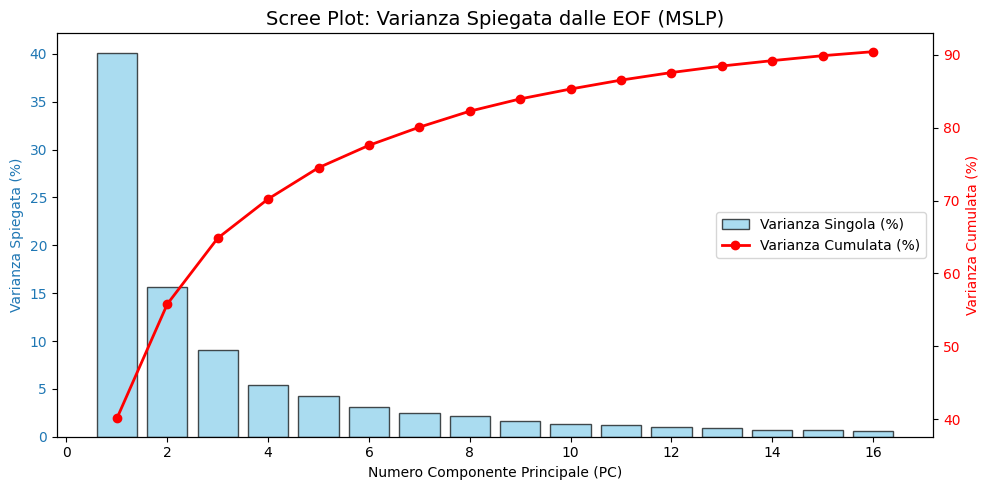

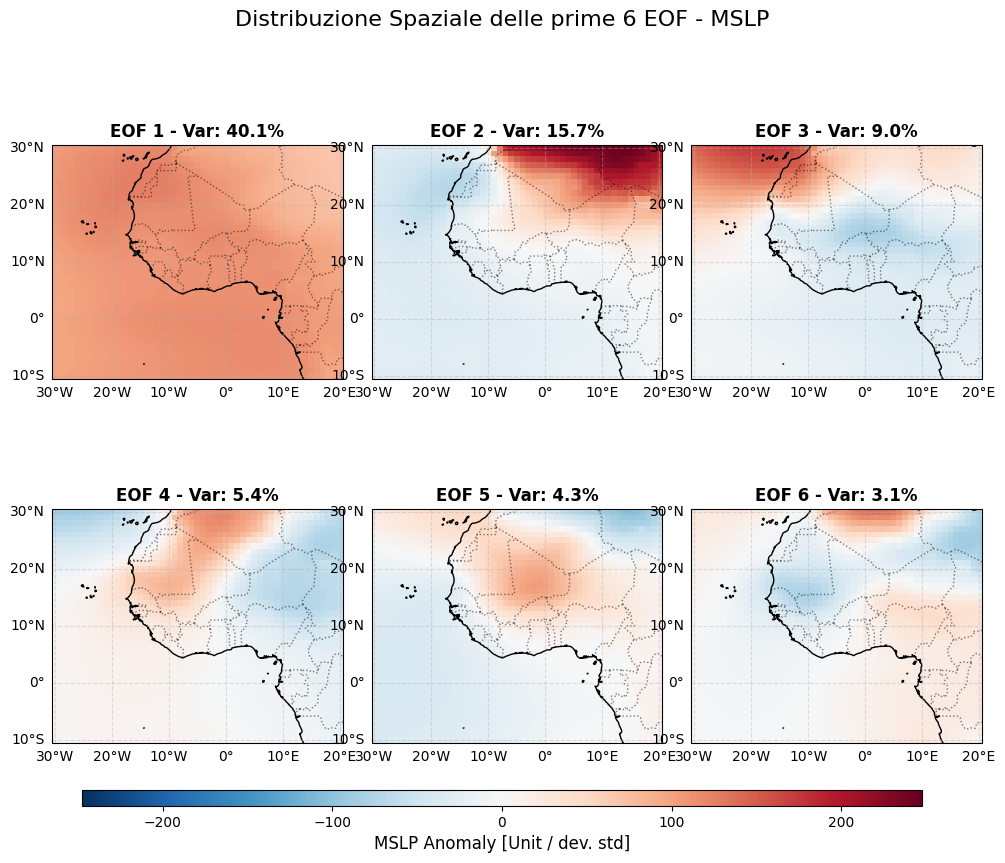

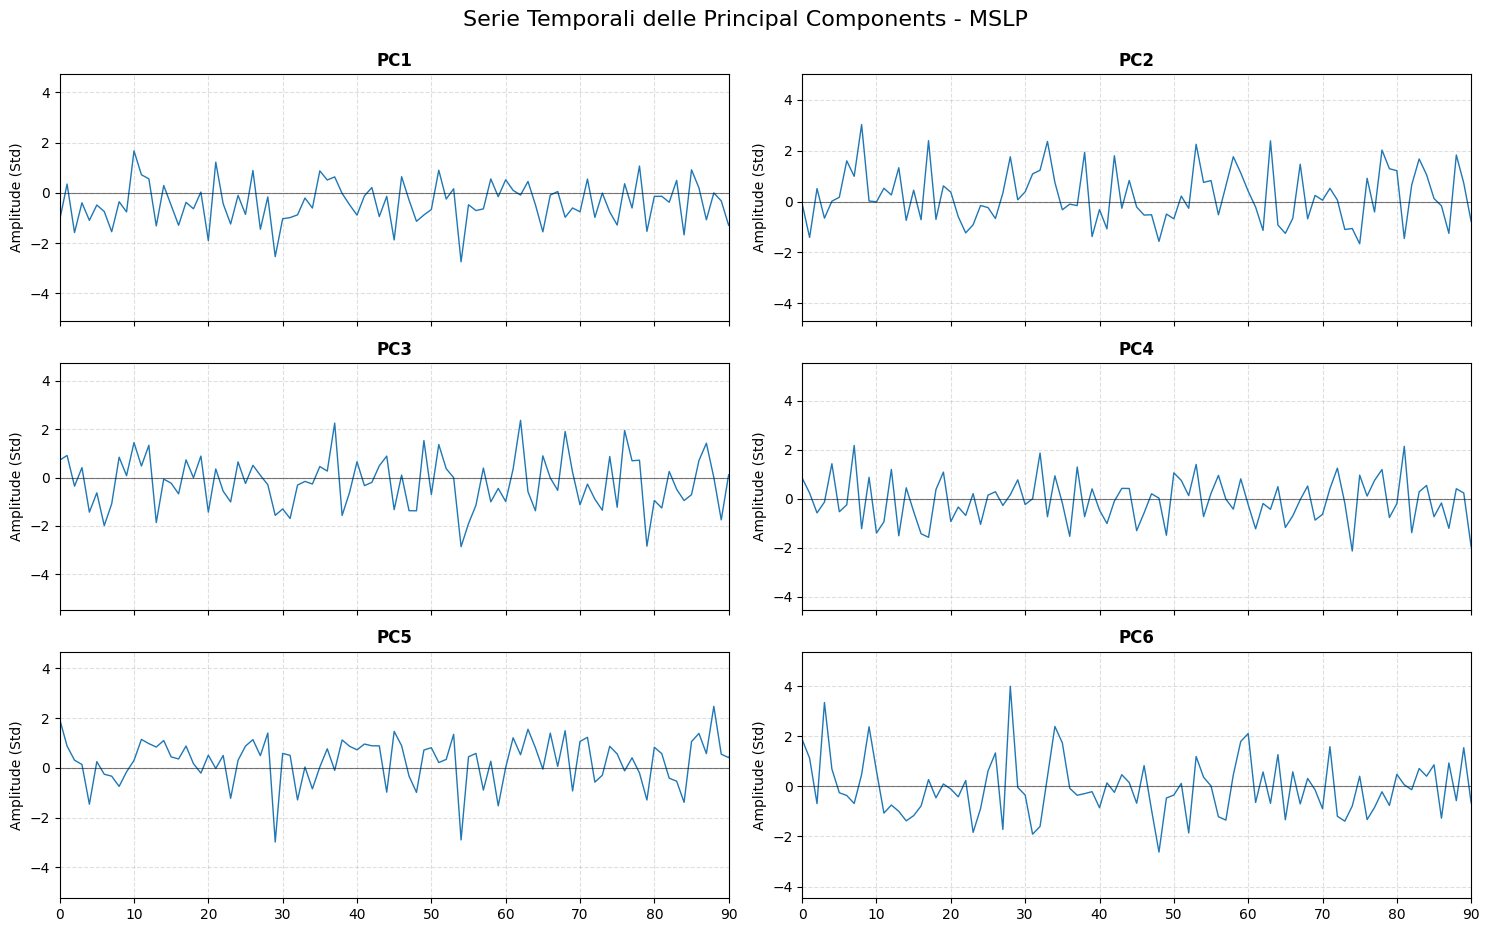

In [62]:
# Voglio vedere lo Scree Plot di tutte le componenti calcolate
plot_scree(mslp_explained_variance, var_name='MSLP')

# Voglio mappare solo le prime 6 EOF
plot_eof_maps(mslp_eofs_dataset, mslp_explained_variance, var_name='MSLP', max_eofs=6)

# Voglio vedere l'andamento temporale delle prime 4 PC
plot_pc_timeseries(mslp_pc_dataframe, var_name='MSLP', max_eofs=6)

In [66]:
z500_final

<xarray.Dataset> Size: 1GB
Dimensions:         (pressure_level: 1, lat: 41, lon: 51, id: 159575)
Coordinates:
  * pressure_level  (pressure_level) float64 8B 500.0
  * lat             (lat) float64 328B 30.0 29.0 28.0 27.0 ... -8.0 -9.0 -10.0
  * lon             (lon) float64 408B -30.0 -29.0 -28.0 ... 18.0 19.0 20.0
  * id              (id) int64 1MB 0 1 2 3 4 ... 159571 159572 159573 159574
Data variables:
    z               (pressure_level, lat, lon, id) float32 1GB 5.791e+04 ... ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-05-29T10:35 GRIB to CDM+CF via cfgrib-0.9.1...

In [78]:
q850_final.info()

xarray.Dataset {
dimensions:
	pressure_level = 1 ;
	lat = 41 ;
	lon = 51 ;
	id = 159575 ;

variables:
	float32 q(pressure_level, lat, lon, id) ;
		q:GRIB_paramId = 133 ;
		q:GRIB_dataType = fc ;
		q:GRIB_numberOfPoints = 2091 ;
		q:GRIB_typeOfLevel = isobaricInhPa ;
		q:GRIB_stepUnits = 1 ;
		q:GRIB_stepType = instant ;
		q:GRIB_gridType = regular_ll ;
		q:GRIB_uvRelativeToGrid = 0 ;
		q:GRIB_NV = 0 ;
		q:GRIB_Nx = 51 ;
		q:GRIB_Ny = 41 ;
		q:GRIB_cfName = specific_humidity ;
		q:GRIB_cfVarName = q ;
		q:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		q:GRIB_iDirectionIncrementInDegrees = 1.0 ;
		q:GRIB_iScansNegatively = 0 ;
		q:GRIB_jDirectionIncrementInDegrees = 1.0 ;
		q:GRIB_jPointsAreConsecutive = 0 ;
		q:GRIB_jScansPositively = 0 ;
		q:GRIB_latitudeOfFirstGridPointInDegrees = 30.0 ;
		q:GRIB_latitudeOfLastGridPointInDegrees = -10.0 ;
		q:GRIB_longitudeOfFirstGridPointInDegrees = -30.0 ;
		q:GRIB_longitudeOfLastGridPointInDegrees = 20.0 ;
		q:GRIB_missingValue = 3.40

In [79]:
### PCA per q850

var_name = 'q'


# 2. Calcola le anomalie usando la funzione
q850_final_squeezed = q850_final.copy()
q850_final_squeezed = q850_final_squeezed.squeeze('pressure_level').drop_vars('pressure_level', errors='ignore')
q850_anomalies = compute_daily_anomalies(q850_final_squeezed, var_name)

# 3. Esegui la PCA sulle anomalie
q850_pc_dataframe, q850_eofs_dataset, q850_explained_variance = perform_pca_workflow(
    ds_anom = q850_anomalies, 
    var_name = var_name, 
    n_components = 0.9 
)


Calcolo anomalie giornaliere per la variabile: q
Avvio workflow PCA per q...
Adattamento del modello PCA in corso...
PCA completata. Modelli ritenuti: 257


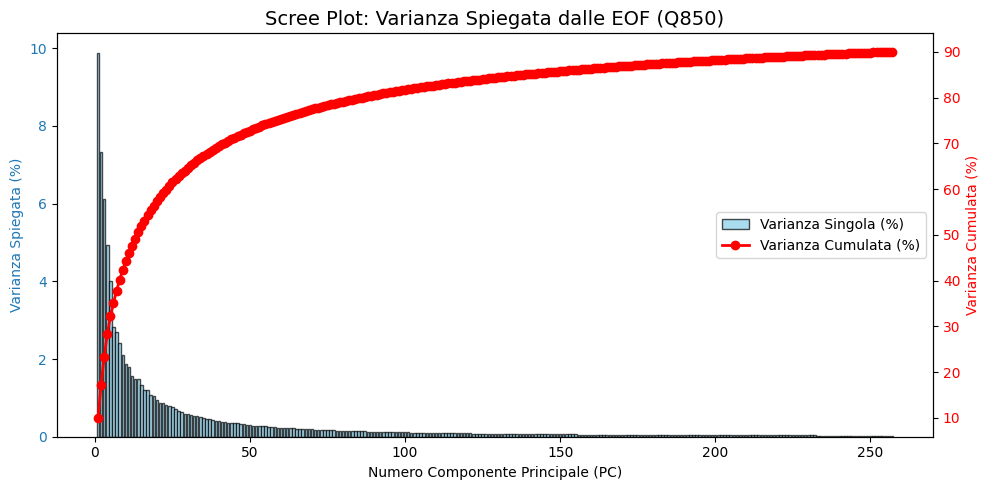

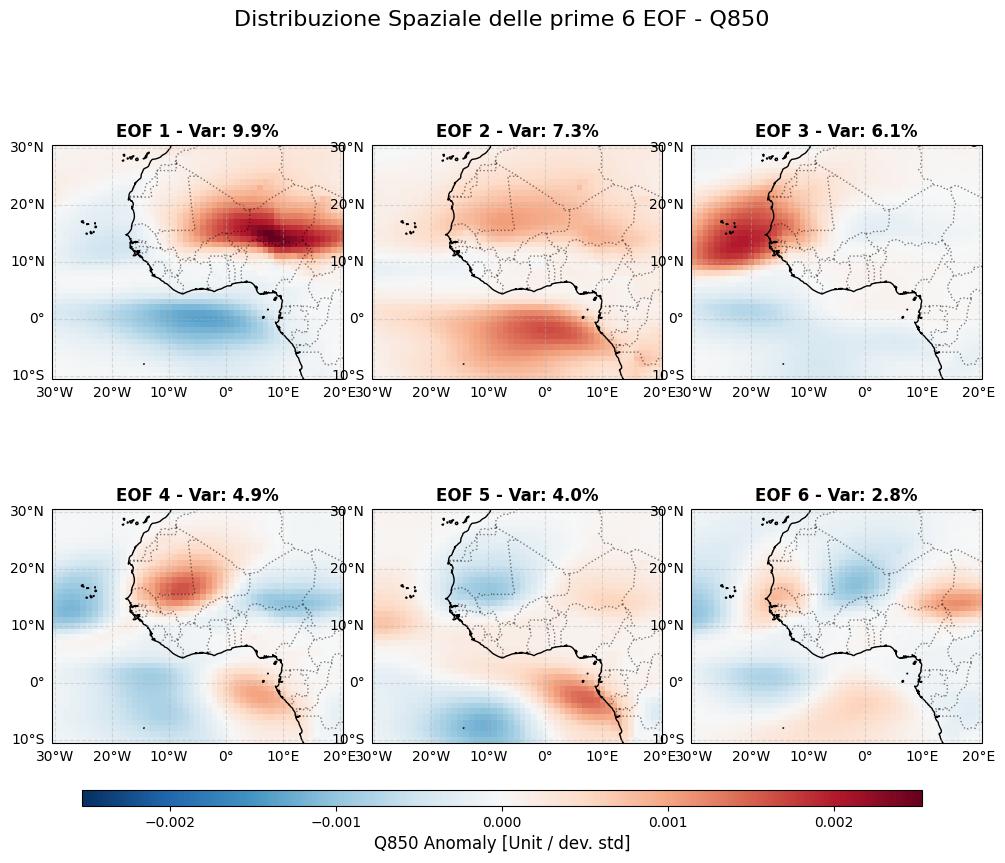

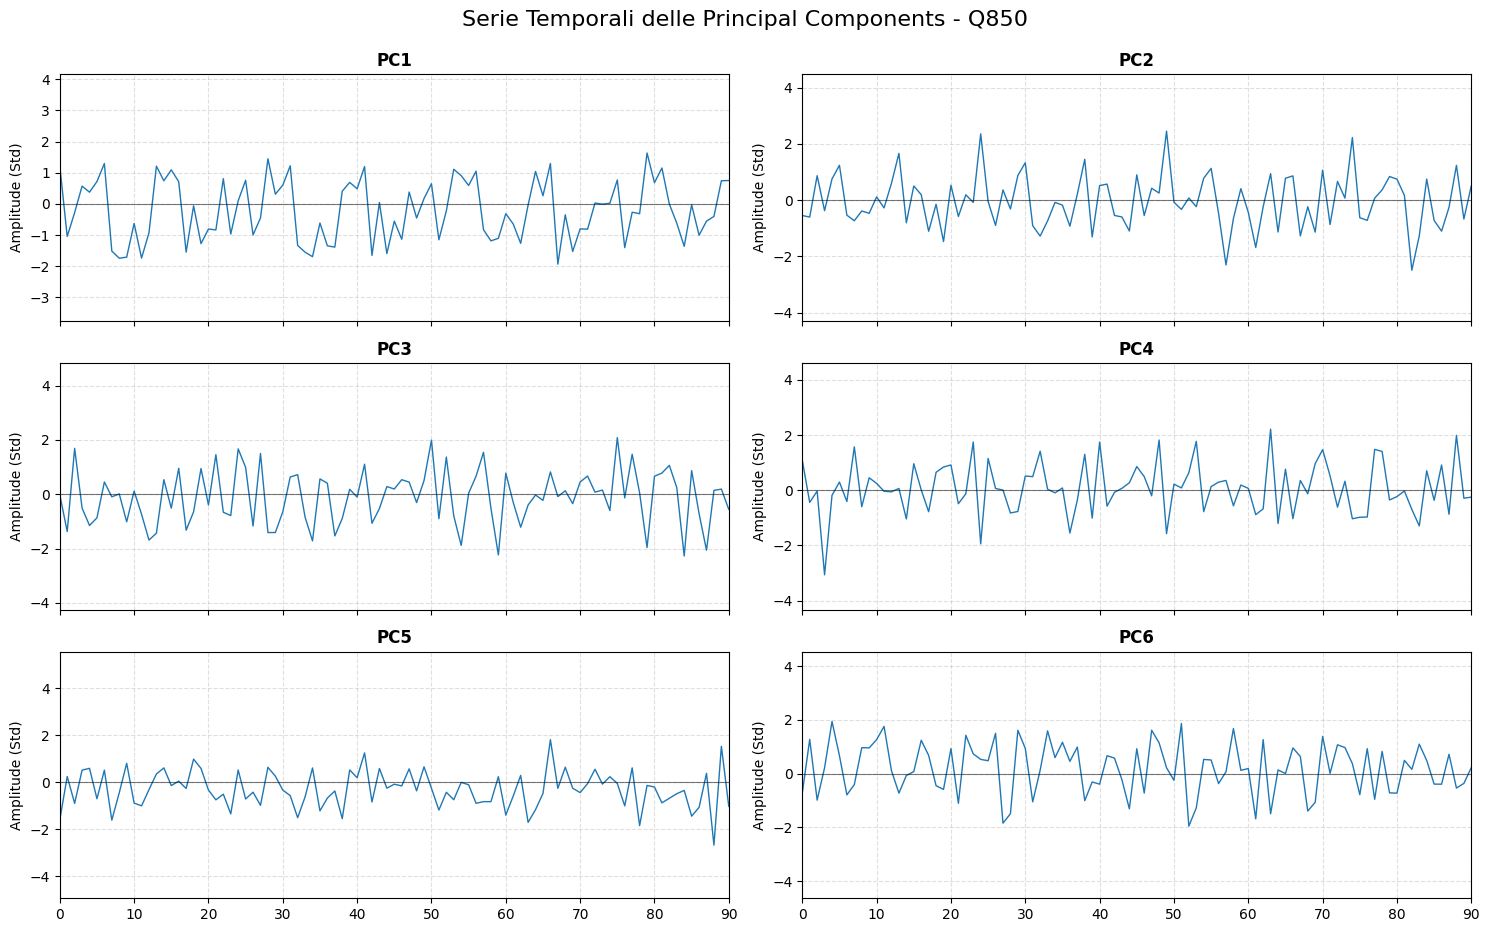

In [80]:
# Voglio vedere lo Scree Plot di tutte le componenti calcolate
plot_scree(q850_explained_variance, var_name='Q850')

# Voglio mappare solo le prime 6 EOF
plot_eof_maps(q850_eofs_dataset, q850_explained_variance, var_name='Q850', max_eofs=6)

# Voglio vedere l'andamento temporale delle prime 4 PC
plot_pc_timeseries(q850_pc_dataframe, var_name='Q850', max_eofs=6)

In [82]:
### PCA per z500

var_name = 'z'


# 2. Calcola le anomalie usando la funzione
z500_final_squeezed = z500_final.copy()
z500_final_squeezed = z500_final_squeezed.squeeze('pressure_level').drop_vars('pressure_level', errors='ignore')
z500_anomalies = compute_daily_anomalies(z500_final_squeezed, var_name)

# 3. Esegui la PCA sulle anomalie
z500_pc_dataframe, z500_eofs_dataset, z500_explained_variance = perform_pca_workflow(
    ds_anom = z500_anomalies, 
    var_name = var_name, 
    n_components = 0.9 
)


Calcolo anomalie giornaliere per la variabile: z
Avvio workflow PCA per z...
Adattamento del modello PCA in corso...
PCA completata. Modelli ritenuti: 7


In [97]:
# salvataggio dei dati in file pickle per uso futuro: 
# z500_final_squeezed, z500_anomalies, z500_pc_dataframe, z500_eofs_dataset, z500_explained_variance
# mslp_final, mslp_anomalies, mslp_pc_dataframe, mslp_eofs_dataset, mslp_explained_variance
# q850_final_squeezed, q850_anomalies, q850_pc_dataframe, q850_eofs_dataset, q850_explained_variance
import pickle
# Salvataggio dei dati in file pickle separati per ogni variabile
with open('./data/processed/pca_results_z500.pkl', 'wb') as f:
    pickle.dump({
        'final_squeezed': z500_final_squeezed,
        'anomalies': z500_anomalies,
        'pc_dataframe': z500_pc_dataframe,
        'eofs_dataset': z500_eofs_dataset,
        'explained_variance': z500_explained_variance
    }, f)
with open('./data/processed/pca_results_mslp.pkl', 'wb') as f:
    pickle.dump({
        'final_squeezed': mslp_final,
        'anomalies': mslp_anomalies,
        'pc_dataframe': mslp_pc_dataframe,
        'eofs_dataset': mslp_eofs_dataset,
        'explained_variance': mslp_explained_variance
    }, f)
with open('./data/processed/pca_results_q850.pkl', 'wb') as f:
    pickle.dump({
        'final_squeezed': q850_final_squeezed,
        'anomalies': q850_anomalies,
        'pc_dataframe': q850_pc_dataframe,
        'eofs_dataset': q850_eofs_dataset,
        'explained_variance': q850_explained_variance
    }, f)


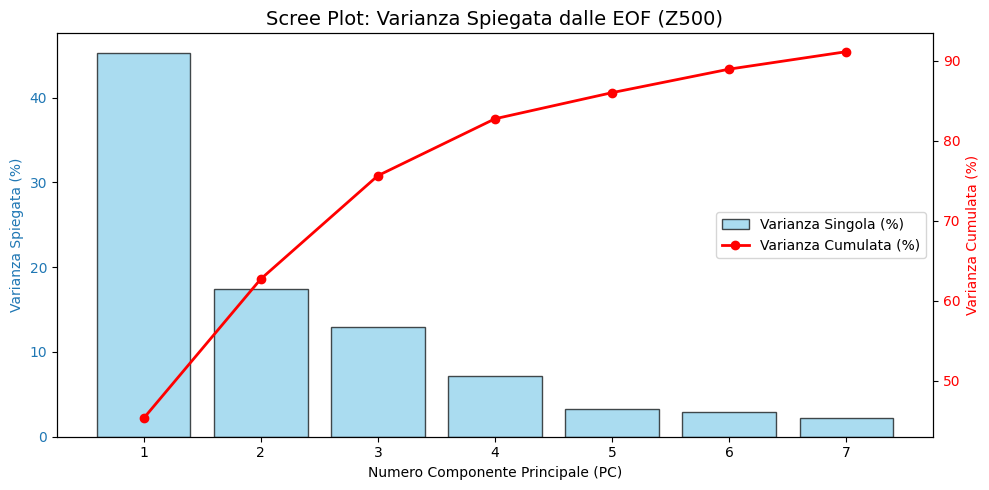

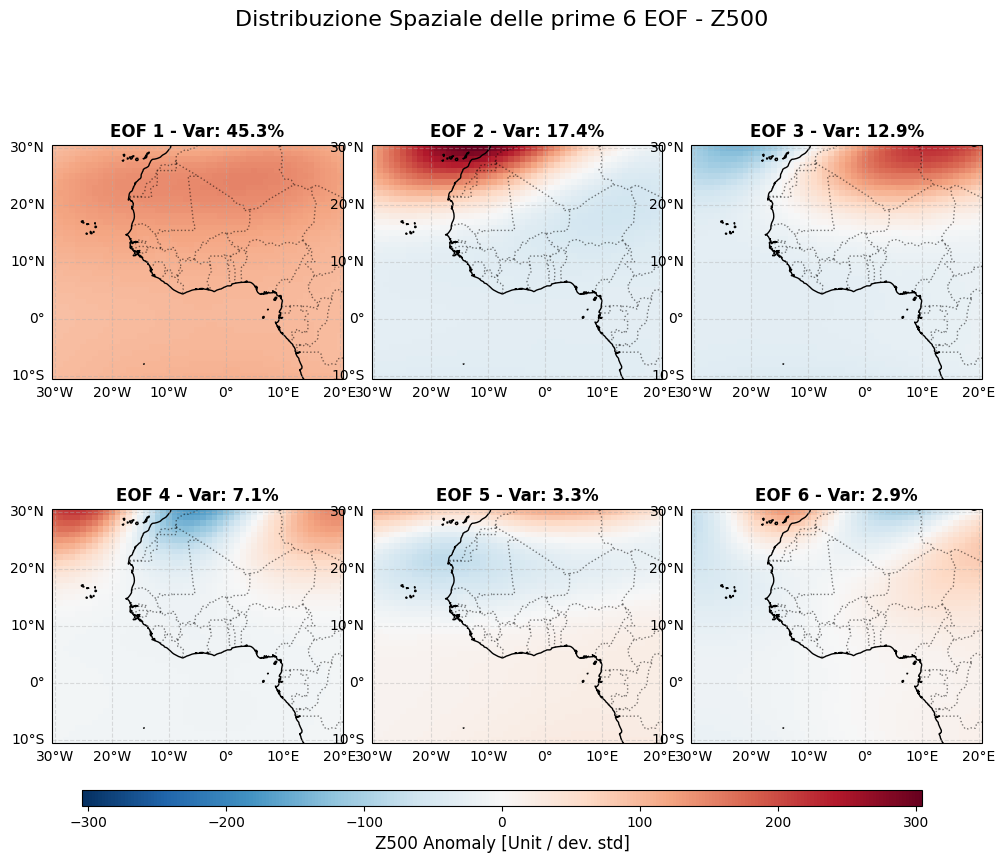

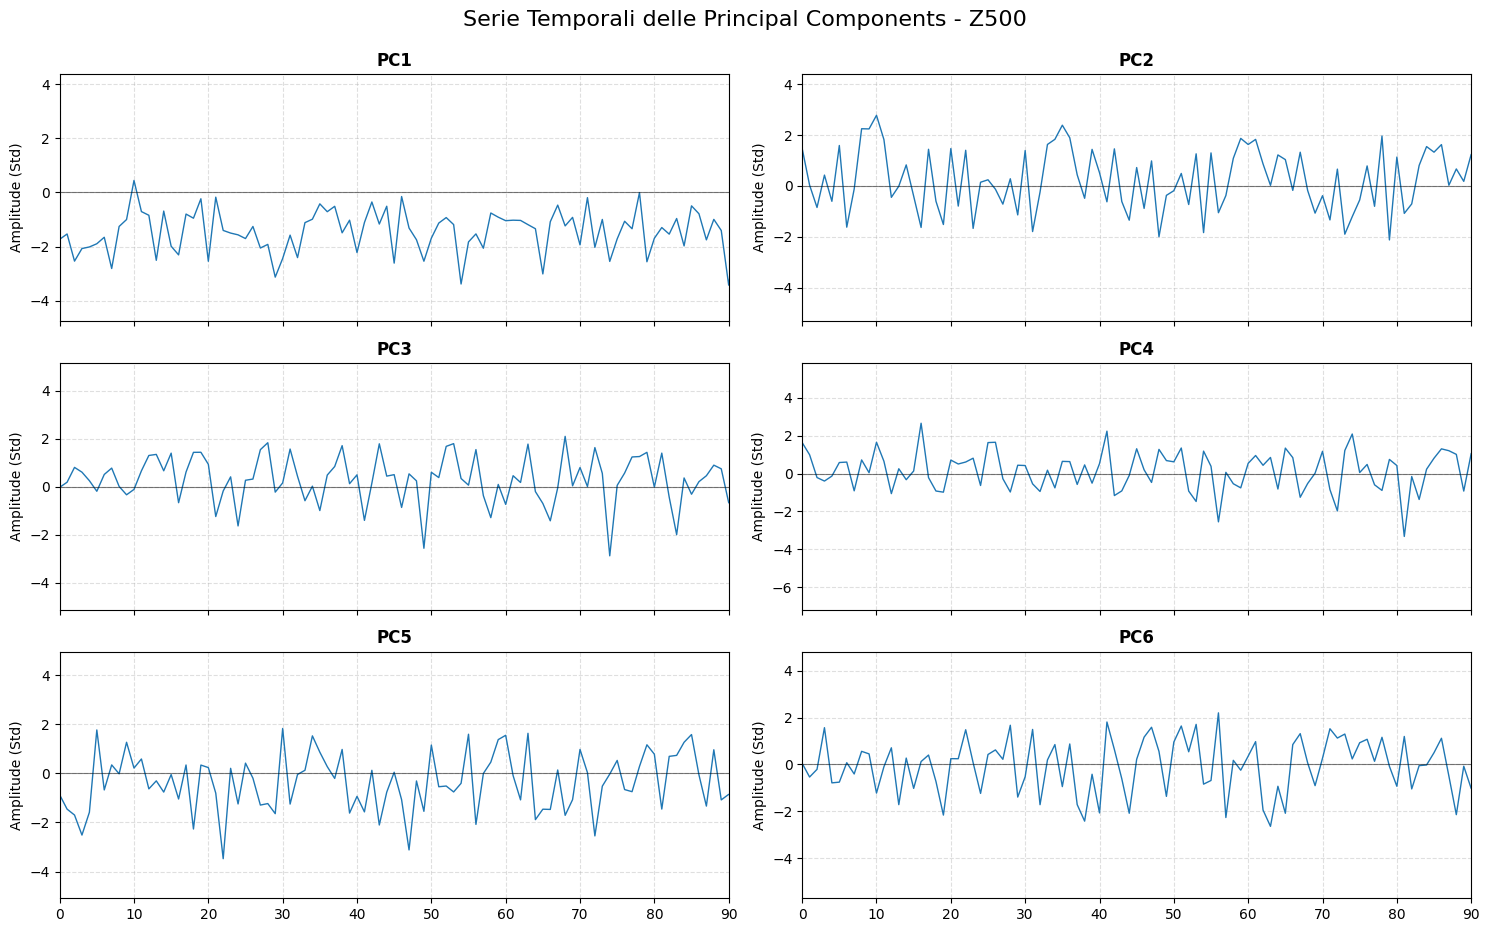

In [83]:
# Voglio vedere lo Scree Plot di tutte le componenti calcolate
plot_scree(z500_explained_variance, var_name='Z500')

# Voglio mappare solo le prime 6 EOF
plot_eof_maps(z500_eofs_dataset, z500_explained_variance, var_name='Z500', max_eofs=6)

# Voglio vedere l'andamento temporale delle prime 4 PC
plot_pc_timeseries(z500_pc_dataframe, var_name='Z500', max_eofs=6)

In [ ]:
z500_pc_dataframe

### FUCKING ML

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, auc, roc_curve

def prepare_ml_dataset(mslp_df, z500_df, q850_df, pot_df):
    """
    Fonde i dataset delle PC e il target POT, estraendo l'anno per il raggruppamento.
    """
    print("Inizio fusione dei dataset...")
    
    # 1. Rinominiamo le colonne PC per distinguerne la provenienza fisica
    # Assumiamo che 'forecast_time' sia presente in mslp_df per estrarre l'anno
    df1 = mslp_df.add_prefix('MSLP_').rename(columns={'MSLP_forecast_time': 'forecast_time'})
    df2 = z500_df.drop(columns=['forecast_time'], errors='ignore').add_prefix('Z500_')
    df3 = q850_df.drop(columns=['forecast_time'], errors='ignore').add_prefix('Q850_')
    
    # 2. Unione orizzontale (assumendo che abbiano lo stesso indice 'id')
    X_full = pd.concat([df1, df2, df3], axis=1)
    
    # 3. Estrazione della coordinata annuale (Gruppi per la Cross-Validation)
    X_full['year'] = X_full['forecast_time'].dt.year
    X_full = X_full.drop(columns=['forecast_time']) # Non serve più al modello
    
    # 4. Allineamento con il target POT
    # Assicurati che pot_df abbia l'id come indice per un merge pulito
    if 'id' in pot_df.columns:
        pot_df = pot_df.set_index('id')
        
    final_df = X_full.join(pot_df['target_pot'], how='inner')
    
    # Separazione feature (X), target (y) e gruppi (groups)
    y = final_df['target_pot']
    groups = final_df['year']
    X = final_df.drop(columns=['target_pot', 'year'])
    
    print(f"Dataset finale pronto: {X.shape[0]} campioni, {X.shape[1]} features.")
    return X, y, groups



def train_rf_gridsearch(X, y, groups):
    """
    Esegue lo split dei dati e avvia la GridSearchCV con GroupKFold.
    """
    # 1. Split in Train e Test
    # Evitiamo lo split casuale, usiamo gli anni per dividere train e test
    # Es. addestriamo fino al 2017, testiamo dal 2018 al 2022
    train_idx = groups < 2018
    test_idx = groups >= 2018
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    groups_train = groups[train_idx]
    
    print(f"Set di addestramento: {len(X_train)} campioni. Set di test: {len(X_test)} campioni.")

    # 2. Configurazione Cross Validation (evita leakage degli ensemble)
    gkf = GroupKFold(n_splits=5)
    
    # 3. Definizione Modello base
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    # 4. Spazio degli iperparametri (incluso il tuning dei pesi richiesto nel Giorno 2)
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_leaf': [5, 10],
        # Bilanciamento base vs bilanciamento aggressivo manuale per alzare la Recall
        'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}] 
    }
    
    print("Avvio GridSearchCV (potrebbe richiedere tempo)...")
    grid_search = GridSearchCV(
        estimator=rf, 
        param_grid=param_grid, 
        cv=gkf, 
        scoring='f1', # Ottimizziamo esplicitamente l'F1-score invece dell'accuratezza
        n_jobs=-1,
        verbose=2
    )
    
    # Fit passando i gruppi
    grid_search.fit(X_train, y_train, groups=groups_train)
    
    print("\nMigliori Iperparametri trovati:")
    print(grid_search.best_params_)
    
    best_model = grid_search.best_estimator_
    
    return best_model, X_test, y_test



def evaluate_and_diagnose(model, X_test, y_test):
    """
    Estrae le metriche diagnostiche, plotta la ROC curve e le Feature Importances.
    """
    print("\n--- INIZIO DIAGNOSTICA (Giorno 2 & 3) ---")
    
    # 1. Predizioni
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probabilità della classe estrema (1)
    
    # 2. Metriche di Classificazione
    print("\nReport di Classificazione:")
    print(classification_report(y_test, y_pred, digits=3))
    
    print("\nMatrice di Confusione:")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    print(f"Veri Estremi catturati (Recall proxy): {cm[1,1]} su {cm[1,0]+cm[1,1]}")
    
    # --- PLOT DIAGNOSTICI ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 3. Curva ROC e calcolo AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate (Recall)')
    ax1.set_title('ROC Curve - Predizione Estremi')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)
    
    # 4. Feature Importance (Top 15 Componenti)
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:15] # Prendiamo le prime 15
    top_features = X_test.columns[indices]
    
    ax2.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
    ax2.set_yticks(range(len(indices)))
    ax2.set_yticklabels(top_features)
    ax2.invert_yaxis()  # La feature più importante in alto
    ax2.set_xlabel('Relative Importance')
    ax2.set_title('Top 15 Feature Importances (Giorno 3)')
    ax2.grid(axis='x', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    return top_features # Restituisce i nomi delle feature per ricollegarle alle mappe spaziali

Inizio fusione dei dataset...
Dataset finale pronto: 159575 campioni, 280 features.
Set di addestramento: 122350 campioni. Set di test: 37225 campioni.
Avvio GridSearchCV (potrebbe richiedere tempo)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=5, n_estimators=100; total time= 2.1min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=5, n_estimators=100; total time= 2.3min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=10, n_estimators=100; total time= 2.5min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=10, n_estimators=100; total time= 2.5min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=5, n_estimators=100; total time= 2.5min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=5, n_estimators=100; total time= 2.5min
[CV] END class_weight=balanced, max_depth=10, min_samples_leaf=5, n_estimators=100; total time= 2.5min
[CV] END clas

/home/PERSONALE/alessandro.zampella2/env/py312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END class_weight={0: 1, 1: 5}, max_depth=10, min_samples_leaf=5, n_estimators=200; total time= 4.4min
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=10, n_estimators=200; total time= 5.1min
[CV] END class_weight={0: 1, 1: 5}, max_depth=10, min_samples_leaf=5, n_estimators=200; total time= 4.4min
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=10, n_estimators=200; total time= 5.5min
[CV] END class_weight={0: 1, 1: 5}, max_depth=15, min_samples_leaf=5, n_estimators=100; total time= 2.9min
[CV] END class_weight={0: 1, 1: 5}, max_depth=15, min_samples_leaf=5, n_estimators=100; total time= 3.1min
[CV] END class_weight=balanced, max_depth=None, min_samples_leaf=10, n_estimators=200; total time= 5.9min
[CV] END class_weight={0: 1, 1: 5}, max_depth=15, min_samples_leaf=5, n_estimators=100; total time= 3.3min
[CV] END class_weight={0: 1, 1: 5}, max_depth=15, min_samples_leaf=5, n_estimators=100; total time= 3.4min
[CV] END class_weight={0: 1, 1: 5}, max_

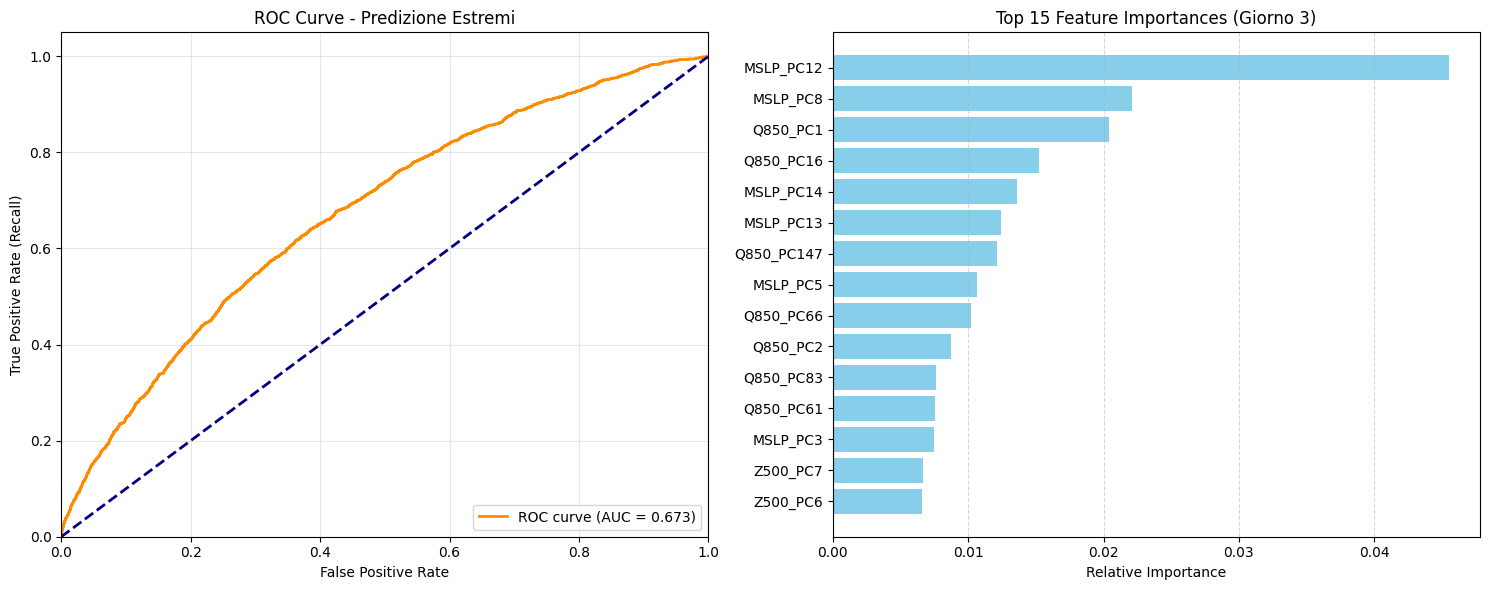

Le componenti che guidano fisicamente il modello sono: ['MSLP_PC12', 'MSLP_PC8', 'Q850_PC1', 'Q850_PC16', 'MSLP_PC14', 'MSLP_PC13', 'Q850_PC147', 'MSLP_PC5', 'Q850_PC66', 'Q850_PC2', 'Q850_PC83', 'Q850_PC61', 'MSLP_PC3', 'Z500_PC7', 'Z500_PC6']


In [89]:
# 1. Unione Dati
X_all, y_all, groups_all = prepare_ml_dataset(
    mslp_pc_dataframe, 
    z500_pc_dataframe, 
    q850_pc_dataframe, 
    df_target
)

# 2. Addestramento (Lascialo girare il pomeriggio!)
best_rf_model, X_test_holdout, y_test_holdout = train_rf_gridsearch(X_all, y_all, groups_all)

# 3. Valutazione e Grafici
top_driving_features = evaluate_and_diagnose(best_rf_model, X_test_holdout, y_test_holdout)

print(f"Le componenti che guidano fisicamente il modello sono: {top_driving_features.tolist()}")

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, auc, roc_curve

def prepare_ml_dataset(features_dict, pot_df):
    """
    Merges a dictionary of feature datasets with the POT target dataset, 
    extracting the temporal coordinate (year) for cross-validation grouping.

    Parameters
    ----------
    features_dict : dict
        A dictionary where keys are string names for the feature groups 
        (e.g., 'MSLP', 'Z500') and values are the corresponding pandas DataFrames.
    pot_df : pandas.DataFrame
        The DataFrame containing the target variable. Must contain a 'target_pot' column 
        and should preferably share the same index ('id') as the feature DataFrames.

    Returns
    -------
    features : pandas.DataFrame
        The fully merged and prefixed feature dataset, excluding target and year.
    target : pandas.Series
        The target variable series for the machine learning model.
    groups : pandas.Series
        The temporal grouping variable (years) extracted for Cross-Validation.
    """
    print("Starting dataset fusion...")
    
    features_list = []
    year_series = None

    # 1. Iterate over the dictionary, extract year, drop forecast_time, and add prefixes
    for name, df in features_dict.items():
        temp_df = df.copy()
        
        if 'forecast_time' in temp_df.columns:
            if year_series is None:
                year_series = temp_df['forecast_time'].dt.year
            temp_df = temp_df.drop(columns=['forecast_time'])
            
        temp_df = temp_df.add_prefix(f"{name}_")
        features_list.append(temp_df)

    # 2. Horizontal concatenation (assuming same 'id' index)
    features_full = pd.concat(features_list, axis=1)
    
    if year_series is None:
        raise ValueError("None of the input DataFrames contained a 'forecast_time' column.")
    features_full['year'] = year_series

    # 3. Alignment with POT target
    if 'id' in pot_df.columns:
        pot_df = pot_df.set_index('id')
        
    final_df = features_full.join(pot_df['target_pot'], how='inner')
    
    # 4. Separation into features, target, and groups
    target = final_df['target_pot']
    groups = final_df['year']
    features = final_df.drop(columns=['target_pot', 'year'])
    
    print(f"Final dataset ready: {features.shape[0]} samples, {features.shape[1]} features.")
    return features, target, groups


def train_rf_gridsearch(features, target, groups, param_grid, test_size=0.2):
    """
    Splits the data based on whole years, initializes a Random Forest, 
    and runs a GridSearchCV utilizing GroupKFold to prevent temporal data leakage.

    Parameters
    ----------
    features : pandas.DataFrame
        The input features for the model.
    target : pandas.Series
        The target variable to predict.
    groups : pandas.Series
        The grouping variable (years) to ensure strict temporal splitting.
    param_grid : dict
        Dictionary with parameters names as keys and lists of parameter settings to try.
    test_size : float, optional
        The approximate proportion of the dataset to include in the test split.
        The algorithm will convert this to a whole number of years. Default is 0.2.

    Returns
    -------
    grid_search : sklearn.model_selection.GridSearchCV
        The fitted GridSearchCV object containing results and the best estimator.
    features_test : pandas.DataFrame
        The subset of features used for testing.
    target_test : pandas.Series
        The subset of target variables used for testing.
    """
    # 1. Determine whole-year splitting to match desired test_size
    unique_years = np.sort(groups.unique())
    n_total_years = len(unique_years)
    
    n_test_years = max(1, int(round(n_total_years * test_size)))
    n_train_years = n_total_years - n_test_years
    
    train_years = unique_years[:n_train_years]
    test_years = unique_years[n_train_years:]
    
    # Create boolean masks
    train_idx = groups.isin(train_years)
    test_idx = groups.isin(test_years)
    
    features_train, features_test = features[train_idx], features[test_idx]
    target_train, target_test = target[train_idx], target[test_idx]
    groups_train = groups[train_idx]
    
    # 2. Print exact split statistics
    actual_test_pct = (len(features_test) / len(features)) * 100
    print(f"--- Data Split Summary ---")
    print(f"Requested test size: {test_size * 100:.1f}%")
    print(f"Train: {n_train_years} years ({train_years[0]} to {train_years[-1]}), {len(features_train)} samples.")
    print(f"Test:  {n_test_years} years ({test_years[0]} to {test_years[-1]}), {len(features_test)} samples.")
    print(f"Actual resulting test percentage: {actual_test_pct:.2f}%\n")

    # 3. Cross-Validation Configuration
    gkf = GroupKFold(n_splits=min(5, n_train_years))
    
    # 4. Base Model Definition (n_jobs=-1 uses all CPU cores)
    rf = RandomForestClassifier(random_state=42, n_jobs=-1)
    
    print("Starting GridSearchCV (this might take a while)...")
    grid_search = GridSearchCV(
        estimator=rf, 
        param_grid=param_grid, 
        cv=gkf, 
        scoring='f1', 
        n_jobs=-1,
        verbose=1
    )
    
    # 5. Model fitting
    grid_search.fit(features_train, target_train, groups=groups_train)
    
    print("\nBest Hyperparameters Found:")
    print(grid_search.best_params_)
    
    return grid_search, features_test, target_test


def plot_grid_search_heatmap(grid_search):
    """
    Extracts results from a fitted GridSearchCV and plots a 2D heatmap 
    evaluating 'n_estimators' vs 'max_depth' while freezing other parameters 
    (like 'class_weight' and 'min_samples_leaf') at their best-found values.
    Uses only Matplotlib (no Seaborn).

    Parameters
    ----------
    grid_search : sklearn.model_selection.GridSearchCV
        The fitted GridSearchCV object.
        
    Returns
    -------
    None
        Displays the matplotlib figure.
    """
    print("\n--- GENERATING GRID SEARCH HEATMAP ---")
    
    results = pd.DataFrame(grid_search.cv_results_)
    best_params = grid_search.best_params_
    
    # Filter results to fix all parameters except max_depth and n_estimators
    mask = pd.Series([True] * len(results))
    
    for param, value in best_params.items():
        if param not in ['max_depth', 'n_estimators']:
            # Convert dictionaries/complex types to string to ensure safe boolean masking
            param_col = f'param_{param}'
            mask &= (results[param_col].astype(str) == str(value))
            
    subset = results[mask].copy()
    
    if subset.empty:
        print("Warning: Could not isolate a 2D grid for the heatmap. Check your param_grid structure.")
        return

    # Handle None values in max_depth for plotting purposes
    subset['param_max_depth'] = subset['param_max_depth'].fillna('None').astype(str)
    
    # Create Pivot Table
    pivot_table = subset.pivot(
        index='param_max_depth', 
        columns='param_n_estimators', 
        values='mean_test_score'
    )
    
    # --- PLOTTING ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # pcolormesh or imshow can be used. imshow is great for matrices.
    cax = ax.imshow(pivot_table.values, cmap='viridis', aspect='auto')
    
    # Set ticks and labels
    ax.set_xticks(np.arange(len(pivot_table.columns)))
    ax.set_yticks(np.arange(len(pivot_table.index)))
    ax.set_xticklabels(pivot_table.columns)
    ax.set_yticklabels(pivot_table.index)
    
    ax.set_xlabel('n_estimators', fontweight='bold')
    ax.set_ylabel('max_depth', fontweight='bold')
    
    # Add title dynamically reporting the fixed class_weight
    fixed_cw = best_params.get('class_weight', 'Default')
    ax.set_title(f'GridSearch F1-Score Heatmap\n(Fixed class_weight: {fixed_cw})', pad=15)
    
    # Add text annotations inside the heatmap cells
    for i in range(len(pivot_table.index)):
        for j in range(len(pivot_table.columns)):
            val = pivot_table.values[i, j]
            if not np.isnan(val):
                # Choose text color based on background intensity for readability
                color = "black" if val > pivot_table.values.max() * 0.8 else "white"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontweight='bold')
                
    # Add colorbar
    cbar = fig.colorbar(cax, ax=ax)
    cbar.set_label('Mean Test F1-Score')
    
    plt.tight_layout()
    plt.show()

In [93]:
# 1. Costruzione del dizionario delle feature con le chiavi desiderate per i prefissi
features_dict = {
    'MSLP': mslp_pc_dataframe,
    'Z500': z500_pc_dataframe,
    'Q850': q850_pc_dataframe
}

# 2. Preparazione del dataset (con i nuovi input e output rinominati)
features_all, target_all, groups_all = prepare_ml_dataset(
    features_dict=features_dict, 
    pot_df=df_target
)


Starting dataset fusion...
Final dataset ready: 159575 samples, 280 features.


In [95]:

# 3. Definizione dello spazio degli iperparametri da passare in input
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [10, 15, None],
    'min_samples_leaf': [5, 10],
    'class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}]
}

# 4. Addestramento con GridSearchCV e split per anni interi (es. 20% test size)
grid_search_results, features_test, target_test = train_rf_gridsearch(
    features=features_all,
    target=target_all,
    groups=groups_all,
    param_grid=param_grid,
    test_size=0.2  # Gestisce internamente lo split a livello di anni interi
)


--- Data Split Summary ---
Requested test size: 20.0%
Train: 24 years (1993 to 2016), 127650 samples.
Test:  6 years (2017 to 2022), 31925 samples.
Actual resulting test percentage: 20.01%

Starting GridSearchCV (this might take a while)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/home/PERSONALE/alessandro.zampella2/env/py312/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best Hyperparameters Found:
{'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 50}



--- GENERATING GRID SEARCH HEATMAP ---


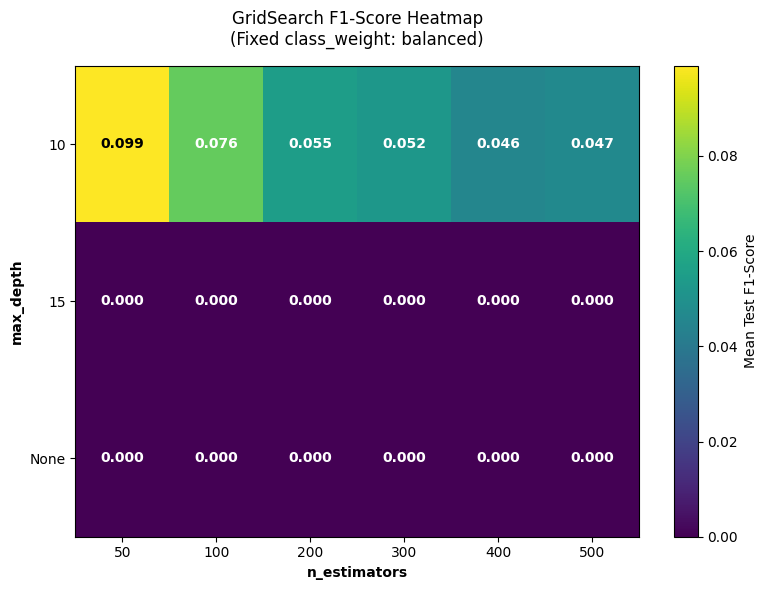

In [96]:

# 5. Generazione dell'heatmap personalizzata (senza Seaborn) sui risultati della GridSearch
plot_grid_search_heatmap(grid_search_results)

In [98]:
# salvataggio di tutti i risultati in pickle: features_all, target_all, groups_all, grid_search_results, features_test, target_test
import pickle
with open('./data/processed/ml_results.pkl', 'wb') as f:
    pickle.dump({
        'features_all': features_all,
        'target_all': target_all,
        'groups_all': groups_all,
        'grid_search_results': grid_search_results,
        'features_test': features_test,
        'target_test': target_test
    }, f)